In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

bhumika44_tod310_path = kagglehub.dataset_download('bhumika44/tod310')

print('Data source import complete.')


[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


✅ Loaded: train=137633, test=29483, pred=29539

📊 LogisticRegression Results
              precision    recall  f1-score   support

    Negative       0.77      0.75      0.76      9082
     Neutral       0.72      0.69      0.71      9123
    Positive       0.84      0.88      0.86     11278

    accuracy                           0.78     29483
   macro avg       0.78      0.78      0.78     29483
weighted avg       0.78      0.78      0.78     29483



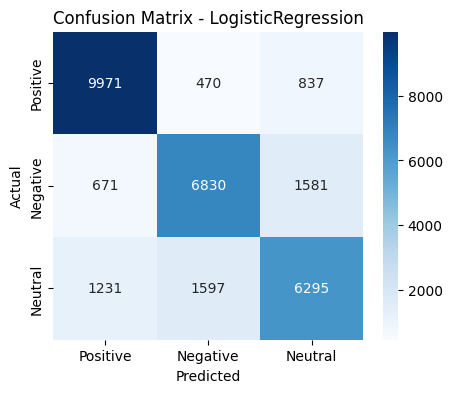


📊 NaiveBayes Results
              precision    recall  f1-score   support

    Negative       0.74      0.73      0.73      9082
     Neutral       0.65      0.56      0.60      9123
    Positive       0.76      0.86      0.81     11278

    accuracy                           0.73     29483
   macro avg       0.72      0.72      0.71     29483
weighted avg       0.72      0.73      0.72     29483



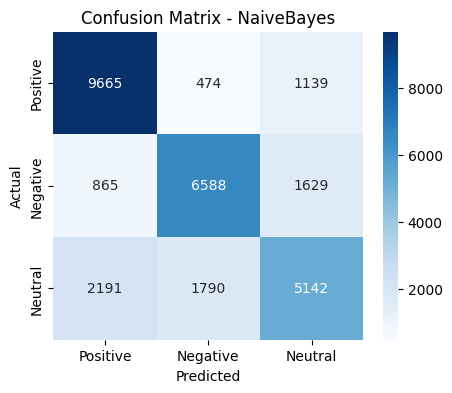


📊 KNN Results
              precision    recall  f1-score   support

    Negative       0.62      0.67      0.64      9082
     Neutral       0.59      0.63      0.61      9123
    Positive       0.82      0.72      0.77     11278

    accuracy                           0.68     29483
   macro avg       0.67      0.67      0.67     29483
weighted avg       0.69      0.68      0.68     29483



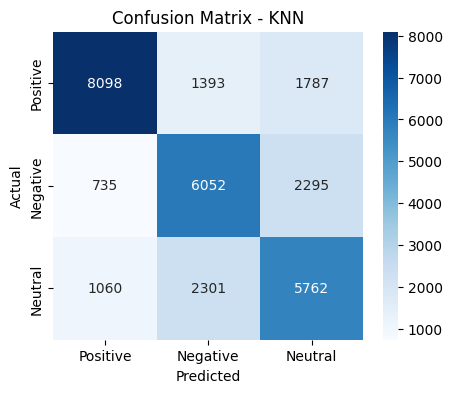


📊 RandomForest Results
              precision    recall  f1-score   support

    Negative       0.77      0.75      0.76      9082
     Neutral       0.74      0.67      0.70      9123
    Positive       0.81      0.89      0.85     11278

    accuracy                           0.78     29483
   macro avg       0.77      0.77      0.77     29483
weighted avg       0.78      0.78      0.78     29483



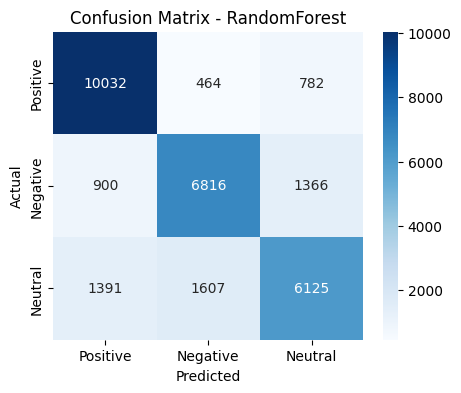


📊 XGBoost Results
              precision    recall  f1-score   support

    Negative       0.76      0.62      0.68      9082
     Neutral       0.62      0.73      0.67      9123
    Positive       0.81      0.83      0.82     11278

    accuracy                           0.73     29483
   macro avg       0.73      0.72      0.72     29483
weighted avg       0.74      0.73      0.73     29483



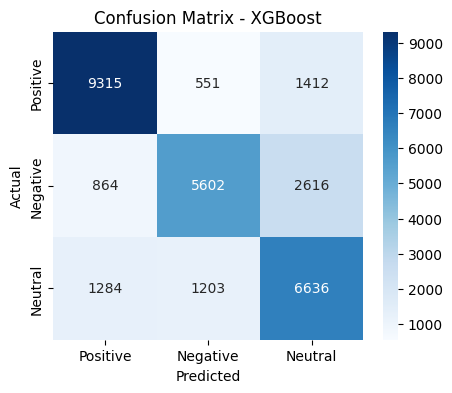

🏆 Best Model: LogisticRegression
✅ Final Excel saved: final_sentiment_output.xlsx


In [ ]:
# Stepwise Sentiment Modeling Pipeline (All models, with Confusion & ROC)
# Kaggle ready - using training, testing, prediction datasets separately

import nltk, re, pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
nltk.download('stopwords')
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    classification_report, accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, roc_curve, auc
)
import xgboost as xgb

# -------------------------------------------------------------------------
# 1. Load data
train_df = pd.read_excel("/kaggle/input/tod310/training_data.xlsx")
test_df  = pd.read_excel("/kaggle/input/tod310/testing_data.xlsx")
pred_df  = pd.read_excel("/kaggle/input/tod310/prediction_data.xlsx")

valid_sentiments = ['Positive', 'Negative', 'Neutral']

train_df = train_df[train_df['predicted_sentiments'].isin(valid_sentiments)]
test_df  = test_df[test_df['predicted_sentiments'].isin(valid_sentiments)]

train_df['Source'] = 'Training'
test_df['Source']  = 'Testing'
pred_df['Source']  = 'Prediction'

print(f"✅ Loaded: train={len(train_df)}, test={len(test_df)}, pred={len(pred_df)}")

# -------------------------------------------------------------------------
# 2. Clean text
stop_words = set(stopwords.words('english'))
def clean_text(text):
    if pd.isna(text): return ""
    text = str(text).lower().strip()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return " ".join([t for t in text.split() if t not in stop_words])

train_df["clean_sentence"] = train_df["Sentence"].apply(clean_text)
test_df["clean_sentence"]  = test_df["Sentence"].apply(clean_text)
pred_df["clean_sentence"]  = pred_df["Sentence"].apply(clean_text)

# -------------------------------------------------------------------------
# 3. TF-IDF
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2), min_df=2)
X_train = tfidf.fit_transform(train_df["clean_sentence"])
X_test  = tfidf.transform(test_df["clean_sentence"])
X_pred  = tfidf.transform(pred_df["clean_sentence"])

y_train = train_df["predicted_sentiments"]
y_test  = test_df["predicted_sentiments"]

# -------------------------------------------------------------------------
# 4. Train models
models, results = {}, {}

def evaluate_model(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average='macro')
    prec = precision_score(y_true, y_pred, average='macro')
    rec  = recall_score(y_true, y_pred, average='macro')
    print(f"\n📊 {name} Results")
    print(classification_report(y_true, y_pred))
    cm = confusion_matrix(y_true, y_pred, labels=valid_sentiments)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=valid_sentiments, yticklabels=valid_sentiments, cmap='Blues')
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
    results[name] = {'y_pred': y_pred, 'accuracy': acc, 'f1': f1, 'precision': prec, 'recall': rec}

# Logistic Regression
lr = LogisticRegression(max_iter=2000, solver='liblinear', multi_class='ovr', random_state=42)
lr.fit(X_train, y_train)
evaluate_model("LogisticRegression", y_test, lr.predict(X_test))
models['LogisticRegression'] = lr

# Naive Bayes
nb = MultinomialNB()
nb.fit(X_train, y_train)
evaluate_model("NaiveBayes", y_test, nb.predict(X_test))
models['NaiveBayes'] = nb

# KNN (SVD)
svd = TruncatedSVD(n_components=150, random_state=42)
scaler = StandardScaler()
X_train_svd = scaler.fit_transform(svd.fit_transform(X_train))
X_test_svd  = scaler.transform(svd.transform(X_test))
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_svd, y_train)
evaluate_model("KNN", y_test, knn.predict(X_test_svd))
models['KNN'] = knn

# Random Forest
rf = RandomForestClassifier(random_state=42)
rf_grid = GridSearchCV(rf, {'n_estimators':[100,200],'max_depth':[None,10]}, cv=3, n_jobs=-1)
rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_
evaluate_model("RandomForest", y_test, best_rf.predict(X_test))
models['RandomForest'] = best_rf

# XGBoost
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)
xgb_clf = xgb.XGBClassifier(
    objective='multi:softprob', eval_metric='mlogloss',
    use_label_encoder=False, random_state=42, device='cpu'
)
xgb_grid = GridSearchCV(xgb_clf, {
    'n_estimators':[100,200], 'max_depth':[3,5], 'learning_rate':[0.05,0.1]
}, cv=3, n_jobs=-1)
xgb_grid.fit(X_train, y_train_enc)
best_xgb = xgb_grid.best_estimator_
evaluate_model("XGBoost", y_test, le.inverse_transform(best_xgb.predict(X_test)))
models['XGBoost'] = best_xgb

# -------------------------------------------------------------------------
# 5. Pick best model
best_model_name = max(results, key=lambda k: results[k]['accuracy'])
best_model = models[best_model_name]
print("🏆 Best Model:", best_model_name)

# -------------------------------------------------------------------------
# 6. Predict on prediction data
if best_model_name == 'KNN':
    X_pred_svd = scaler.transform(svd.transform(X_pred))
    pred_df["Predicted_Sentiment"] = best_model.predict(X_pred_svd)
elif best_model_name == 'XGBoost':
    pred_df["Predicted_Sentiment"] = le.inverse_transform(best_model.predict(X_pred))
else:
    pred_df["Predicted_Sentiment"] = best_model.predict(X_pred)

# -------------------------------------------------------------------------
# 7. Combine & Save
train_df["Predicted_Sentiment"] = lr.predict(X_train)
test_df["Predicted_Sentiment"]  = lr.predict(X_test)

final_df = pd.concat([train_df, test_df, pred_df], ignore_index=True)

keep_cols = [
    'product','Manufacturer','date','title','rating','body','clean_review','Sentence',
    'Most_Similar_Characteristic','Highest_Similarity_Score','Actuation_Score',
    'Awareness_Score','Connectivity_Score','Dynamism_Score','Novelty_Score',
    'Personality_Score','Source','Predicted_Sentiment'
]

final_df = final_df[keep_cols]
final_df.to_excel("final_sentiment_output.xlsx", index=False)
print("✅ Final Excel saved: final_sentiment_output.xlsx")


In [ ]:
from IPython.display import FileLink
FileLink('final_sentiment_output.xlsx')


/kaggle/working/final_sentiment_output.xlsx

In [ ]:
import pandas as pd

# Load the file
df = pd.read_excel("final_sentiment_output.xlsx")

# Keep only prediction rows
pred_df = df[df["Source"] == "Prediction"].copy()
print(f"Filtered {len(pred_df)} prediction records out of {len(df)} total.")


Filtered 29539 prediction records out of 196655 total.


In [ ]:
sentiment_map = {'Negative': -1, 'Neutral': 0, 'Positive': 1}
pred_df['Sentiment_Score'] = pred_df['Predicted_Sentiment'].map(sentiment_map)
corr = pred_df['rating'].corr(pred_df['Sentiment_Score'])
print(f"🔗 Correlation between sentiment and rating (Prediction only): {corr:.3f}")


🔗 Correlation between sentiment and rating (Prediction only): 0.529


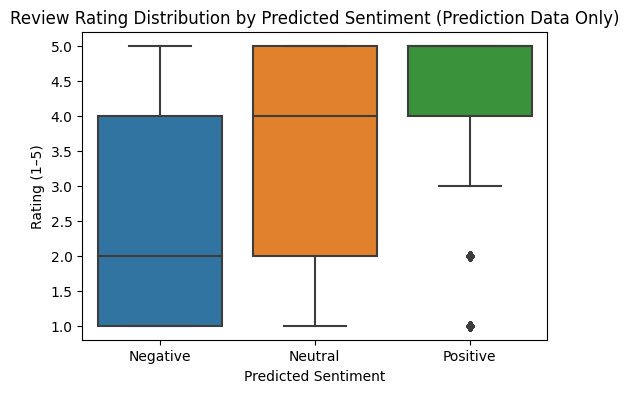

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.boxplot(x='Predicted_Sentiment', y='rating', data=pred_df, order=['Negative','Neutral','Positive'])
plt.title("Review Rating Distribution by Predicted Sentiment (Prediction Data Only)")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Rating (1–5)")
plt.show()


In [ ]:
from scipy.stats import f_oneway, kruskal

neg = pred_df[pred_df['Predicted_Sentiment']=='Negative']['rating']
neu = pred_df[pred_df['Predicted_Sentiment']=='Neutral']['rating']
pos = pred_df[pred_df['Predicted_Sentiment']=='Positive']['rating']

anova_result = f_oneway(neg, neu, pos)
print("ANOVA p-value:", anova_result.pvalue)

if anova_result.pvalue < 0.05:
    print("✅ Significant difference between groups (sentiment influences rating)")
else:
    print("❌ No significant difference between groups")

# Optional non-parametric test
kruskal_result = kruskal(neg, neu, pos)
print("Kruskal–Wallis p-value:", kruskal_result.pvalue)


ANOVA p-value: 0.0
✅ Significant difference between groups (sentiment influences rating)
Kruskal–Wallis p-value: 0.0


In [ ]:
import pandas as pd
import statsmodels.formula.api as smf

# ✅ Step 1. Load and filter only Prediction data
df = pd.read_excel("final_sentiment_output.xlsx")
pred_df = df[df["Source"] == "Prediction"].copy()
print(f"Filtered {len(pred_df)} prediction records out of {len(df)} total.")

# ✅ Step 2. Encode sentiment numerically
sentiment_map = {'Negative': -1, 'Neutral': 0, 'Positive': 1}
pred_df["Sentiment_Score"] = pred_df["Predicted_Sentiment"].map(sentiment_map)

# ✅ Step 3. Simple OLS: Rating explained by Sentiment
model = smf.ols("rating ~ Sentiment_Score", data=pred_df).fit()
print("\n=== Simple OLS: Rating ~ Sentiment_Score ===")
print(model.summary())

# ✅ Step 4 (Optional): Extended OLS with smartness constructs
extended_model = smf.ols("""
    rating ~ Sentiment_Score
           + Actuation_Score
           + Awareness_Score
           + Connectivity_Score
           + Dynamism_Score
           + Novelty_Score
           + Personality_Score
""", data=pred_df).fit()

print("\n=== Extended OLS: Rating ~ Sentiment + Smartness Constructs ===")
print(extended_model.summary())


Filtered 29539 prediction records out of 196655 total.

=== Simple OLS: Rating ~ Sentiment_Score ===
                            OLS Regression Results                            
Dep. Variable:                 rating   R-squared:                       0.280
Model:                            OLS   Adj. R-squared:                  0.280
Method:                 Least Squares   F-statistic:                 1.150e+04
Date:                Sat, 01 Nov 2025   Prob (F-statistic):               0.00
Time:                        17:13:10   Log-Likelihood:                -48823.
No. Observations:               29539   AIC:                         9.765e+04
Df Residuals:                   29537   BIC:                         9.767e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-------------------------

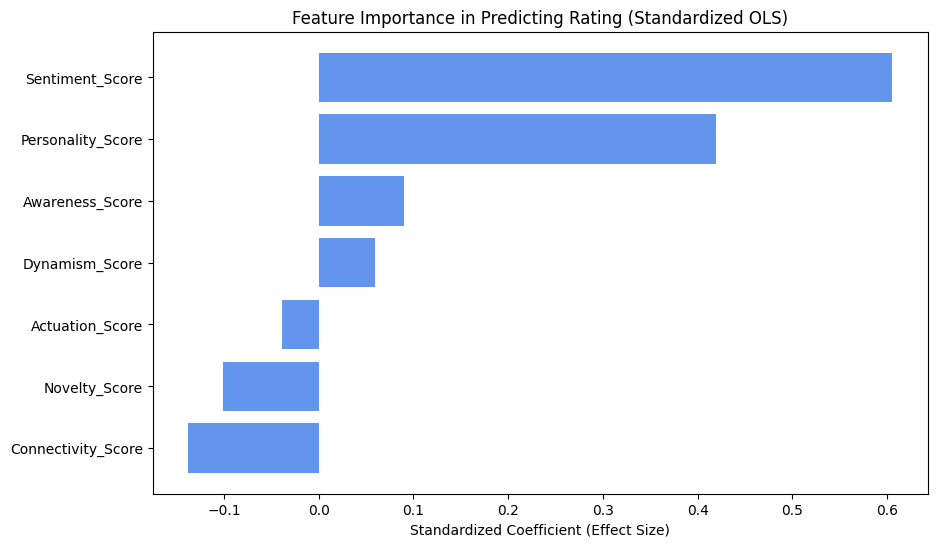


=== Standardized OLS: Comparing Relative Influence ===
                            OLS Regression Results                            
Dep. Variable:                 rating   R-squared:                       0.324
Model:                            OLS   Adj. R-squared:                  0.324
Method:                 Least Squares   F-statistic:                     2023.
Date:                Sat, 01 Nov 2025   Prob (F-statistic):               0.00
Time:                        17:20:50   Log-Likelihood:                -47896.
No. Observations:               29539   AIC:                         9.581e+04
Df Residuals:                   29531   BIC:                         9.587e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------

In [ ]:
# ✅ Step 5: Standardized coefficients (effect size comparison)
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import statsmodels.api as sm
import numpy as np

# Select predictors from your extended model
features = [
    "Sentiment_Score", "Actuation_Score", "Awareness_Score",
    "Connectivity_Score", "Dynamism_Score", "Novelty_Score", "Personality_Score"
]

X = pred_df[features]
y = pred_df["rating"]

# Drop rows with any NaN or infinite values
X = X.replace([np.inf, -np.inf], np.nan).dropna()
y = y.loc[X.index]

# Standardize predictors
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=features, index=X.index)

# Add constant for intercept
X_scaled = sm.add_constant(X_scaled)

# Fit standardized OLS model
model_std = sm.OLS(y, X_scaled).fit()

# ✅ Step 6: Plot standardized coefficients
std_coefs = model_std.params[1:].sort_values(ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(std_coefs.index, std_coefs.values, color="cornflowerblue")
plt.xlabel("Standardized Coefficient (Effect Size)")
plt.title("Feature Importance in Predicting Rating (Standardized OLS)")
plt.gca().invert_yaxis()
plt.show()

# ✅ Print standardized regression summary
print("\n=== Standardized OLS: Comparing Relative Influence ===")
print(model_std.summary())
